# NB03 — Feature Engineering
**Camino de Santiago · Facteurs structurels 2004-2024**

Construit les 22 features candidates issues des 4 axes de recherche.
- Input  : `data/processed/` — schéma stabilisé NB01/NB02
- Output : `data/processed/features_nb03.csv`

## 0 · Setup

In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path

ROOT      = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
FIGURES   = ROOT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.dpi'] = 120

# ── Constantes projet ─────────────────────────────────────────────────────────
SANITARY_YEARS   = [2020, 2021, 2022]
DETREND_YEAR_REF = (2015, 2019)          # fenêtre OLS tendance pré-COVID

# Noms de routes tels qu'ils apparaissent dans master_routes.csv (avec accents)
ROUTES_CORE          = ['Camino Francés', 'Camino del Norte', 'Camino Portugués',
                         'Camino Portugués Costa', 'Camino Primitivo',
                         'Camino Inglés', 'Vía de la Plata']
CHALLENGE_ROUTES     = ['Camino del Norte', 'Camino Primitivo', 'Vía de la Plata']
ACCESSIBILITY_ROUTES = ['Camino Portugués Costa', 'Camino Inglés']

TRENDS_CONFIG = {'PT': [2], 'KR': [0, 1], 'FR': [0], 'DE': [1]}

# Normalisation nom de route → nom de colonne (convention NB02 df_feat)
def to_share_col(route: str) -> str:
    return ('share_' + route.replace(' ', '_')
            .replace('é', 'e').replace('í', 'i').replace('ú', 'u'))

# ── Helpers ───────────────────────────────────────────────────────────────────
def make_lags(df: pd.DataFrame, col: str, lags: list,
              prefix: str = '') -> pd.DataFrame:
    """Retourne un DataFrame avec les lags demandés pour une colonne."""
    label = prefix or col
    return pd.DataFrame(
        {f'{label}_lag{lag}': df[col].shift(lag) for lag in lags},
        index=df.index
    )

def linear_detrend(series: pd.Series) -> pd.Series:
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    s = series.replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) < 5:
        return pd.Series(np.nan, index=series.index, name=series.name + '_dt')
    x     = s.index.astype(float)
    trend = np.poly1d(np.polyfit(x, s.values, deg=1))(x)
    return pd.Series(s.values - trend, index=s.index, name=series.name + '_dt')

print('Setup OK')

Setup OK


## 1 · Chargement des données

In [25]:
# master_annual — totaux officiels + indicateurs comportementaux
ma = pd.read_csv(PROCESSED / 'master_annual.csv', index_col='year').sort_index()

# master_routes — format LONG (year, route, count) → pivot wide
mr = (
    pd.read_csv(PROCESSED / 'master_routes.csv')
    .pivot_table(index='year', columns='route', values='count', aggfunc='sum')
    .fillna(0)
)

# era5_climate_monthly — colonnes : year, month, route, temp_c, precip_mm
#   valeurs route : camino_frances / camino_norte / camino_portugues /
#                   camino_portugues_costa / via_podiensis_fr
era = pd.read_csv(PROCESSED / 'era5_climate_monthly.csv')

# trends_annual — format LONG (year, geo, interest_mean) → pivot wide
df_trends = (
    pd.read_csv(PROCESSED / 'trends_annual.csv')
    .pivot_table(index='year', columns='geo', values='interest_mean')
    .rename(columns=lambda g: f'trends_{g}')
    .sort_index()
)

# trail_sj_annual — colonnes : year, total_finishers, n_countries, …
trail = pd.read_csv(PROCESSED / 'trail_sj_annual.csv', index_col='year').sort_index()

total = ma['total_pilgrims']

print(f'master_annual  : {ma.shape}    | {ma.index.min()}–{ma.index.max()}')
print(f'master_routes  : {mr.shape}    | routes : {list(mr.columns)}')
print(f'trends (pivot) : {df_trends.shape}   | {list(df_trends.columns)}')
print(f'era5_climate   : {era.shape}')
print(f'trail_sj       : {trail.shape}   | {list(trail.columns)}')

master_annual  : (21, 16)    | 2004–2024
master_routes  : (21, 10)    | routes : ['Camino Francés', 'Camino Inglés', 'Camino Portugués', 'Camino Portugués Costa', 'Camino Primitivo', 'Camino de Invierno', 'Camino del Norte', 'Muxía-Finisterre', 'Other routes', 'Vía de la Plata']
trends (pivot) : (21, 9)   | ['trends_BR', 'trends_DE', 'trends_ES', 'trends_FR', 'trends_GB', 'trends_IT', 'trends_KR', 'trends_PT', 'trends_US']
era5_climate   : (1260, 5)
trail_sj       : (11, 3)   | ['total_finishers', 'n_countries', 'pct_women']


## 2 · Axe A — Sensibilité climatique

In [26]:
# A1 · Température estivale Via Podiensis (JJA), lag=1
era_vp_summer = (
    era[(era['route'] == 'via_podiensis_fr') & (era['month'].isin([6, 7, 8]))]
    .groupby('year')['temp_c']
    .mean()
)
feat_A = pd.DataFrame(
    {'via_podiensis_fr_summer_temp_lag1': era_vp_summer.shift(1)}
)

# A2 · Anomalie thermique estivale par corridor (déviation / moyenne longue période)
era_s = era[era['month'].isin([6, 7, 8])].copy()
era_s['temp_anomaly'] = (
    era_s['temp_c'] - era_s.groupby('route')['temp_c'].transform('mean')
)
temp_anom = (
    era_s.groupby(['year', 'route'])['temp_anomaly']
    .mean()
    .unstack('route')
    .rename(columns=lambda c: f'temp_anomaly_{c}')
)
feat_A = feat_A.join(temp_anom, how='outer')

# A3 · ratio_sequential — proxy pèlerinage séquentiel FR→ES
#      ⚠ PROXY : pct_foot / 100 (master_annual)
#        Données SJPDP non disponibles (cf. NB00)
feat_A['ratio_sequential'] = ma['pct_foot'] / 100

# A4 · sanitary_regime — défini une fois, réutilisé en Axe D
sanitary_regime = pd.Series(
    ma.index.isin(SANITARY_YEARS).astype(int), index=ma.index, name='sanitary_regime'
)
feat_A['sanitary_regime'] = sanitary_regime

print(f'Axe A : {feat_A.shape[1]} features')
feat_A.tail()

Axe A : 8 features


,via_podiensis_fr_summer_temp_lag1,temp_anomaly_camino_frances,temp_anomaly_camino_norte,temp_anomaly_camino_portugues,temp_anomaly_camino_portugues_costa,temp_anomaly_via_podiensis_fr,ratio_sequential,sanitary_regime
year,,,,,,,,
2020,20.343333,-0.141587,-0.064921,0.215238,0.186667,-0.001270,0.9236,1
2021,19.936667,-0.708254,-0.751587,-0.804762,-0.740000,-0.654603,0.9284,1
2022,19.283333,1.381746,0.951746,1.098571,0.896667,1.738730,0.9305,1
2023,21.676667,0.905079,1.015079,0.741905,0.603333,0.978730,0.9318,0
2024,20.916667,0.365079,0.221746,0.261905,0.276667,-0.067937,0.9308,0


## 3 · Axe B — Effet médias

In [27]:
feat_B = pd.concat(
    [make_lags(df_trends, f'trends_{geo}', lags)
     for geo, lags in TRENDS_CONFIG.items()],
    axis=1,
)

# Trail SJ — colonnes source : total_finishers / n_countries
feat_B = feat_B.join(make_lags(trail, 'n_countries',    [1], prefix='trail_countries'))
feat_B = feat_B.join(make_lags(trail, 'total_finishers',[0], prefix='trail_finishers'))

print(f'Axe B : {feat_B.shape[1]} features | {list(feat_B.columns)}')
feat_B.tail()

Axe B : 7 features | ['trends_PT_lag2', 'trends_KR_lag0', 'trends_KR_lag1', 'trends_FR_lag0', 'trends_DE_lag1', 'trail_countries_lag1', 'trail_finishers_lag0']


,trends_PT_lag2,trends_KR_lag0,trends_KR_lag1,trends_FR_lag0,trends_DE_lag1,trail_countries_lag1,trail_finishers_lag0
year,,,,,,,
2020,53.75,15.08,44.17,46.75,54.08,NaN,NaN
2021,66.25,14.75,15.08,51.25,42.58,7.0,1138.0
2022,34.67,25.08,14.75,56.83,35.42,12.0,1977.0
2023,47.50,24.75,25.08,62.92,42.67,27.0,3195.0
2024,58.42,21.42,24.75,54.17,42.92,46.0,4205.0


## 4 · Axe C — Diversification géographique

In [28]:
# C1 · diversity_core = 1 − HHI sur routes core
core_shares = mr[ROUTES_CORE].div(mr[ROUTES_CORE].sum(axis=1), axis=0)
feat_C = pd.DataFrame({'diversity_core': 1 - (core_shares ** 2).sum(axis=1)})

# C2-3 · Shares clusters challenge / accessibilité
feat_C['challenge_routes_share']     = mr[CHALLENGE_ROUTES].sum(axis=1) / total
feat_C['accessibility_routes_share'] = mr[ACCESSIBILITY_ROUTES].sum(axis=1) / total

# C4 · phase_regime catégoriel — 3 phases structurelles identifiées NB02
phase_bins   = [2003, 2009, 2017, 2030]
phase_labels = [1, 2, 3]
feat_C['phase_regime'] = pd.cut(
    feat_C.index, bins=phase_bins, labels=phase_labels
).astype(int)

# C5 · growth_momentum_avg — index val_t / roll3(t-1..t-3), hors Francés
non_frances = [r for r in ROUTES_CORE if r != 'Camino Francés']
momentum    = mr[non_frances].div(
    mr[non_frances].shift(1).rolling(3, min_periods=2).mean()
)
feat_C['growth_momentum_avg'] = momentum.mean(axis=1)

# C6 · francés_saturation — proxy régime de concentration (share > 65%)
feat_C['frances_saturation'] = (mr['Camino Francés'] / total > 0.65).astype(int)

print(f'Axe C : {feat_C.shape[1]} features | {list(feat_C.columns)}')
feat_C.tail()

Axe C : 6 features | ['diversity_core', 'challenge_routes_share', 'accessibility_routes_share', 'phase_regime', 'growth_momentum_avg', 'frances_saturation']


,diversity_core,challenge_routes_share,accessibility_routes_share,phase_regime,growth_momentum_avg,frances_saturation
year,,,,,,
2020,0.701644,0.146102,0.128485,3,0.193524,0
2021,0.688166,0.135109,0.137150,3,0.749531,0
2022,0.680639,0.128847,0.151108,3,2.184731,0
2023,0.697101,0.129073,0.171523,3,2.045866,0
2024,0.702286,0.116448,0.209828,3,1.398608,0


## 5 · Axe D — Résilience post-crise

In [29]:
feat_D = pd.DataFrame(index=ma.index)

# D1-2 · Années saintes (holy_year natif master_annual ; compound isolé 2021)
feat_D['holy_year']          = ma['holy_year']
feat_D['holy_year_compound'] = (feat_D.index == 2021).astype(int)

# D3 · post_covid_regime
feat_D['post_covid_regime'] = (feat_D.index >= 2022).astype(int)

# D4 · deferred_demand — déficit cumulé vs tendance OLS pré-COVID
y0, y1    = DETREND_YEAR_REF
ref       = ma.loc[y0:y1, 'total_pilgrims']
trend_fn  = np.poly1d(np.polyfit(ref.index.astype(float), ref.values, deg=1))
projected = pd.Series(trend_fn(ma.index.astype(float)), index=ma.index)
feat_D['deferred_demand'] = (projected - total).clip(lower=0).cumsum()

# D5 · sanitary_regime — réutilisation série définie en Axe A
feat_D['sanitary_regime'] = sanitary_regime

# D6 · yoy_growth_lag1 — composante autorégressive
feat_D['yoy_growth_lag1'] = ma['yoy_growth'].shift(1)

print(f'Axe D : {feat_D.shape[1]} features | {list(feat_D.columns)}')
feat_D.tail()

Axe D : 6 features | ['holy_year', 'holy_year_compound', 'post_covid_regime', 'deferred_demand', 'sanitary_regime', 'yoy_growth_lag1']


,holy_year,holy_year_compound,post_covid_regime,deferred_demand,sanitary_regime,yoy_growth_lag1
year,,,,,,
2020,0,0,0,321831.8,1,0.0617
2021,1,1,0,537493.4,1,-0.8447
2022,0,0,1,537493.4,1,2.2502
2023,0,0,1,537493.4,0,1.4975
2024,0,0,1,537493.4,0,0.0179


## 6 · Assemblage : matrice features + cibles

In [30]:
# Noms de colonnes cibles normalisés selon convention NB02 (é→e, í→i)
targets = pd.DataFrame({
    to_share_col('Camino Portugués Costa') : mr['Camino Portugués Costa'] / total,
    to_share_col('Camino Francés')         : mr['Camino Francés']         / total,
    'total_pilgrims'                        : ma['total_pilgrims'],
    'pct_women'                             : ma['pct_women'],
    'diversity_core'                        : feat_C['diversity_core'],
    to_share_col('Vía de la Plata')         : mr['Vía de la Plata']        / total,
    'share_challenge'                       : feat_C['challenge_routes_share'],
}, index=ma.index)

features = pd.concat([feat_A, feat_B, feat_C, feat_D], axis=1)
matrix   = pd.concat([targets, features], axis=1).sort_index()
matrix   = matrix.loc[:, ~matrix.columns.duplicated()]   # ← ajouter cette ligne
matrix.index.name = 'year'

print(f'Matrice : {matrix.shape}  ({len(targets.columns)} cibles  +  {len(features.columns)} features)')
print(f'Cibles  : {list(targets.columns)}')
matrix.head()

Matrice : (21, 32)  (7 cibles  +  27 features)
Cibles  : ['share_Camino_Portugues_Costa', 'share_Camino_Frances', 'total_pilgrims', 'pct_women', 'diversity_core', 'share_Via_de_la_Plata', 'share_challenge']


,share_Camino_Portugues_Costa,share_Camino_Frances,total_pilgrims,pct_women,diversity_core,share_Via_de_la_Plata,share_challenge,via_podiensis_fr_summer_temp_lag1,temp_anomaly_camino_frances,temp_anomaly_camino_norte,...,challenge_routes_share,accessibility_routes_share,phase_regime,growth_momentum_avg,frances_saturation,holy_year,holy_year_compound,post_covid_regime,deferred_demand,yoy_growth_lag1
year,,,,,,,,,,,,,,,,,,,,,
2004,0.0,0.770495,179944,44.19,0.386074,0.051733,0.118381,NaN,0.008413,0.071746,...,0.118381,0.017183,1,NaN,1,1,0,0,0.0,NaN
2005,0.0,0.845322,93924,40.69,0.273491,0.033431,0.085292,19.756667,0.458413,0.391746,...,0.085292,0.006931,1,NaN,1,0,0,0,0.0,NaN
2006,0.0,0.820975,100377,40.81,0.314567,0.035098,0.104496,20.173333,0.545079,0.591746,...,0.104496,0.008010,1,0.624168,1,0,0,0,0.0,-0.4780
2007,0.0,0.805711,114026,41.43,0.337386,0.036772,0.110791,20.496667,-1.261587,-0.914921,...,0.110791,0.009515,1,0.896986,1,0,0,0,0.0,0.0687
2008,0.0,0.788942,125141,41.72,0.362657,0.040786,0.118730,18.686667,-0.958254,-0.718254,...,0.118730,0.011595,1,1.511046,1,0,0,0,0.0,0.1360


## 7 · Validation

In [31]:
# ── 7.1 · Rapport NA ─────────────────────────────────────────────────────────
na_report = (
    matrix.isna().sum()
    .rename('n_missing')
    .to_frame()
    .assign(pct=lambda d: (d['n_missing'] / len(matrix) * 100).round(1))
    .query('n_missing > 0')
    .sort_values('n_missing', ascending=False)
)
print('── Rapport NA ──────────────────────────────────────────────────────────')
print(na_report.to_string() if not na_report.empty else '  Aucun NA ✓')

── Rapport NA ──────────────────────────────────────────────────────────
                                   n_missing   pct
trail_countries_lag1                      11  52.4
trail_finishers_lag0                      10  47.6
trends_PT_lag2                             2   9.5
growth_momentum_avg                        2   9.5
yoy_growth_lag1                            2   9.5
trends_DE_lag1                             1   4.8
via_podiensis_fr_summer_temp_lag1          1   4.8
trends_KR_lag1                             1   4.8


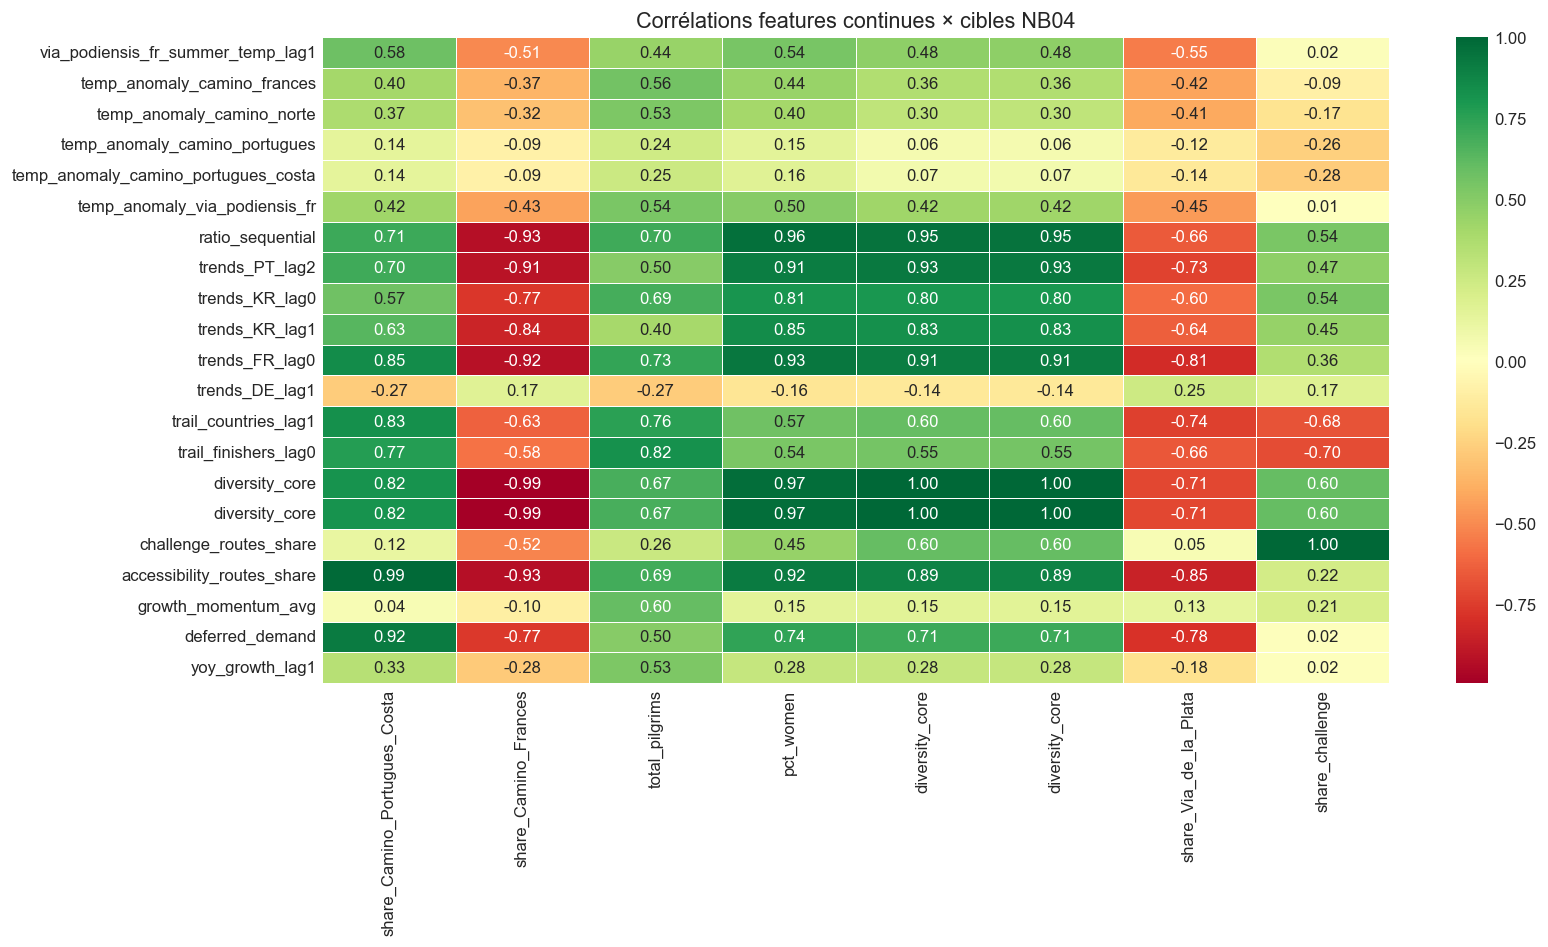

In [32]:
# ── 7.2 · Heatmap corrélations features continues × cibles ───────────────────
BINARY_COLS = ['holy_year', 'holy_year_compound', 'post_covid_regime',
               'sanitary_regime', 'frances_saturation', 'phase_regime']
feat_cont   = [c for c in features.columns if c not in BINARY_COLS]
target_cols = list(targets.columns)

corr_mat = matrix[target_cols + feat_cont].corr().loc[feat_cont, target_cols]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, ax=ax)
ax.set_title('Corrélations features continues × cibles NB04', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'NB03_corr_features_targets.png', dpi=150)
plt.show()

In [33]:
# ── 7.3 · VIF (features continues, fenêtre commune sans NA) ──────────────────
vif_data = matrix[feat_cont].replace([np.inf, -np.inf], np.nan).dropna()
vif_df   = (
    pd.DataFrame({
        'feature': feat_cont,
        'VIF'    : [variance_inflation_factor(vif_data.values, i)
                    for i in range(len(feat_cont))],
    })
    .sort_values('VIF', ascending=False)
)
print('── VIF ─────────────────────────────────────────────────────────────────')
print(vif_df.round(2).to_string(index=False))

high_vif = vif_df[vif_df['VIF'] > 10]
if not high_vif.empty:
    print(f"\n  ⚠ VIF > 10 → surveiller en NB04 : {list(high_vif['feature'])}")

── VIF ─────────────────────────────────────────────────────────────────
                            feature  VIF
  via_podiensis_fr_summer_temp_lag1  inf
        temp_anomaly_camino_frances  inf
          temp_anomaly_camino_norte  inf
      temp_anomaly_camino_portugues  inf
temp_anomaly_camino_portugues_costa  inf
      temp_anomaly_via_podiensis_fr  inf
                   ratio_sequential  inf
                     trends_PT_lag2  inf
                     trends_KR_lag0  inf
                     trends_KR_lag1  inf
                     trends_FR_lag0  inf
                     trends_DE_lag1  inf
               trail_countries_lag1  inf
               trail_finishers_lag0  inf
                     diversity_core  inf
             challenge_routes_share  inf
         accessibility_routes_share  inf
                growth_momentum_avg  inf
                    deferred_demand  inf
                    yoy_growth_lag1  inf

  ⚠ VIF > 10 → surveiller en NB04 : ['via_podiensis_fr_summer_tem

c:\Users\cello\Desktop\camino_datascience\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


## 8 · Détrending

In [34]:
DETREND_COLS = [
    'via_podiensis_fr_summer_temp_lag1', 'ratio_sequential',
    'trends_PT_lag2', 'trends_KR_lag0', 'trends_KR_lag1',
    'trends_FR_lag0', 'trends_DE_lag1',
    'trail_finishers_lag0', 'trail_countries_lag1',
    'diversity_core',
]
dt_series = [linear_detrend(matrix[c]) for c in DETREND_COLS if c in matrix.columns]
matrix    = pd.concat([matrix] + dt_series, axis=1)

print(f'Détrending : {len(dt_series)} séries _dt ajoutées | matrice finale : {matrix.shape}')

Détrending : 10 séries _dt ajoutées | matrice finale : (21, 42)


## 9 · Export

In [35]:
OUT = PROCESSED / 'features_nb03.csv'
matrix.to_csv(OUT)
print(f'✅  features_nb03.csv  →  {OUT}')
print(f'    {matrix.shape[0]} années  ×  {matrix.shape[1]} colonnes')

✅  features_nb03.csv  →  C:\Users\cello\Desktop\camino_datascience\data\processed\features_nb03.csv
    21 années  ×  42 colonnes
